<a href="https://colab.research.google.com/github/AAdi-112/Bitcoin-Sentiment-Trader-Performance-Analysis/blob/main/crypto_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install pandas numpy matplotlib seaborn scipy -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('darkgrid')


In [ ]:
FEAR_GREED_PATH = '/content/fear_greed_index.csv'
TRADER_PATH     = '/content/historical_data.csv'

In [ ]:
fg_df     = pd.read_csv(FEAR_GREED_PATH)
trader_df = pd.read_csv(TRADER_PATH)

print('Fear & Greed Dataset:')
print(f'  Shape: {fg_df.shape}  →  {fg_df.shape[0]} rows, {fg_df.shape[1]} columns')
print()
print('Trader Dataset:')
print(f'  Shape: {trader_df.shape}  →  {trader_df.shape[0]} rows, {trader_df.shape[1]} columns')

Fear & Greed Dataset:
  Shape: (2644, 4)  →  2644 rows, 4 columns

Trader Dataset:
  Shape: (211224, 16)  →  211224 rows, 16 columns


In [ ]:
print('Fear & Greed Index - First 5 Rows')
fg_df.head()

Fear & Greed Index - First 5 Rows


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print('Trader Data - First 5 Rows')
trader_df.head()

Trader Data - First 5 Rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
print(' Fear & Greed: Before Cleaning ')
print(fg_df.dtypes)
print('\nNull values:', fg_df.isnull().sum().to_dict())

# Converting date column to datetime
fg_df['date'] = pd.to_datetime(fg_df['date'])

# Keeping things that we need, and changing names for better understanding
fg_df = fg_df[['date', 'value', 'classification']].copy()
fg_df.rename(columns={'value': 'fg_value', 'classification': 'sentiment'}, inplace=True)

# Sorting by date
fg_df = fg_df.sort_values('date').reset_index(drop=True)

print('\n Fear & Greed: After Cleaning')
print(fg_df.dtypes)
print('\nSentiment categories:', fg_df['sentiment'].unique())
fg_df.head()

 Fear & Greed: Before Cleaning 
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Null values: {'timestamp': 0, 'value': 0, 'classification': 0, 'date': 0}

 Fear & Greed: After Cleaning
date         datetime64[ns]
fg_value              int64
sentiment            object
dtype: object

Sentiment categories: ['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']


,date,fg_value,sentiment
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


In [9]:
print(' Trader Data: Column Names ')
print(trader_df.columns.tolist())
print('\n Data Types ')
print(trader_df.dtypes)

 Trader Data: Column Names 
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

 Data Types 
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [10]:
trader_df.columns = trader_df.columns.str.lower().str.strip().str.replace(' ', '_')

print('Cleaned column names:')
print(trader_df.columns.tolist())

Cleaned column names:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


In [23]:
# Identify the time column (common names: 'time', 'timestamp', 'date')e
time_col = 'timestamp'

# Convert timestamp (milliseconds) to datetime
trader_df['date'] = pd.to_datetime(trader_df[time_col], unit='ms').dt.normalize()  # strip time, keep date

# Convert closedPnL to numeric (remove any $ signs or commas if present)
pnl_col = 'closed_pnl'
trader_df[pnl_col] = pd.to_numeric(trader_df[pnl_col], errors='coerce')

# Droping rows where PnL is missing
trader_df.dropna(subset=[pnl_col], inplace=True)

print(f'Trader data after cleaning: {trader_df.shape[0]} rows')
print(f'Date range: {trader_df["date"].min().date()} to {trader_df["date"].max().date()}')
trader_df[['account','coin', 'side', pnl_col, 'date']].head()

Trader data after cleaning: 211224 rows
Date range: 2023-03-28 to 2025-06-15


,account,coin,side,closed_pnl,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,2024-10-27


In [24]:
print('Missing Values Summary')
print('\nFear & Greed:')
print(fg_df.isnull().sum())
print('\nTrader Data:')
print(trader_df.isnull().sum())

Missing Values Summary

Fear & Greed:
date         0
fg_value     0
sentiment    0
dtype: int64

Trader Data:
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
dtype: int64


In [25]:
print(f'Fear & Greed duplicate rows: {fg_df.duplicated().sum()}')
print(f'Trader duplicate rows: {trader_df.duplicated().sum()}')

# Drop duplicates if any
fg_df.drop_duplicates(inplace=True)
trader_df.drop_duplicates(inplace=True)

print('\n Duplicates removed sussessfully!')

Fear & Greed duplicate rows: 0
Trader duplicate rows: 0

 Duplicates removed sussessfully!


**Fear and greed index analysis**

In [26]:
# Basic statistics of Fear & Greed Index
print('Fear & Greed Index - Summary Statistics')
print(fg_df['fg_value'].describe())

print('\n Sentiment Distribution')
sentiment_counts = fg_df['sentiment'].value_counts()
print(sentiment_counts)

Fear & Greed Index - Summary Statistics
count    2644.000000
mean       46.981089
std        21.827680
min         5.000000
25%        28.000000
50%        46.000000
75%        66.000000
max        95.000000
Name: fg_value, dtype: float64

 Sentiment Distribution
sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


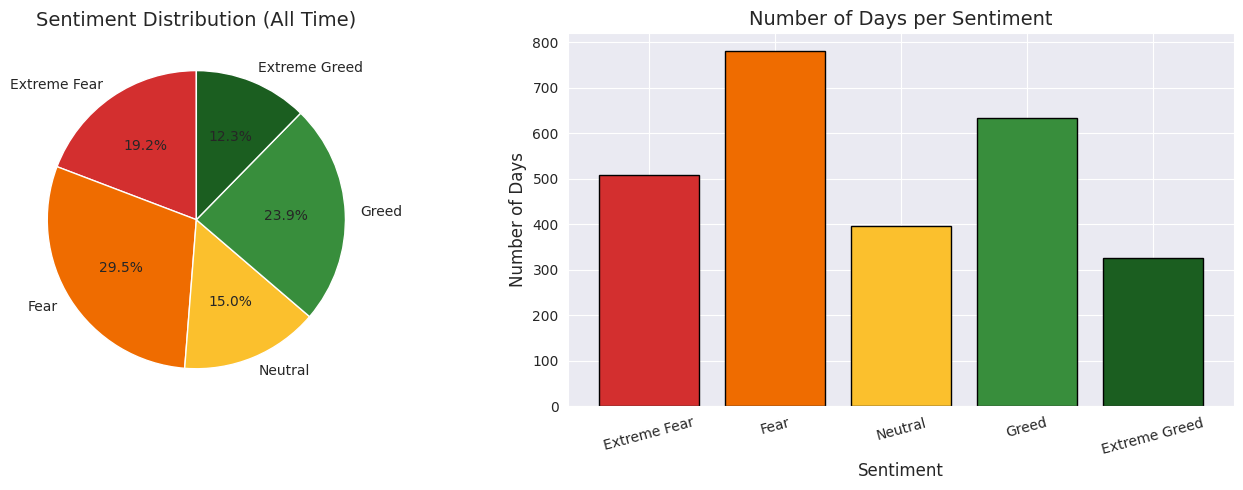

In [27]:
# Plot 1: Sentiment Distribution (Pie + Bar)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color scheme matching sentiment
sentiment_order  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = ['#d32f2f', '#ef6c00', '#fbc02d', '#388e3c', '#1b5e20']

# Filter to only present categories
present = [s for s in sentiment_order if s in sentiment_counts.index]
colors  = [sentiment_colors[sentiment_order.index(s)] for s in present]

# Pie chart
axes[0].pie(
    sentiment_counts[present],
    labels=present,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0].set_title('Sentiment Distribution (All Time)')

# Bar chart
axes[1].bar(present, sentiment_counts[present], color=colors, edgecolor='black')
axes[1].set_title('Number of Days per Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Days')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('plot1_sentiment_distribution.png', dpi=150)
plt.show()


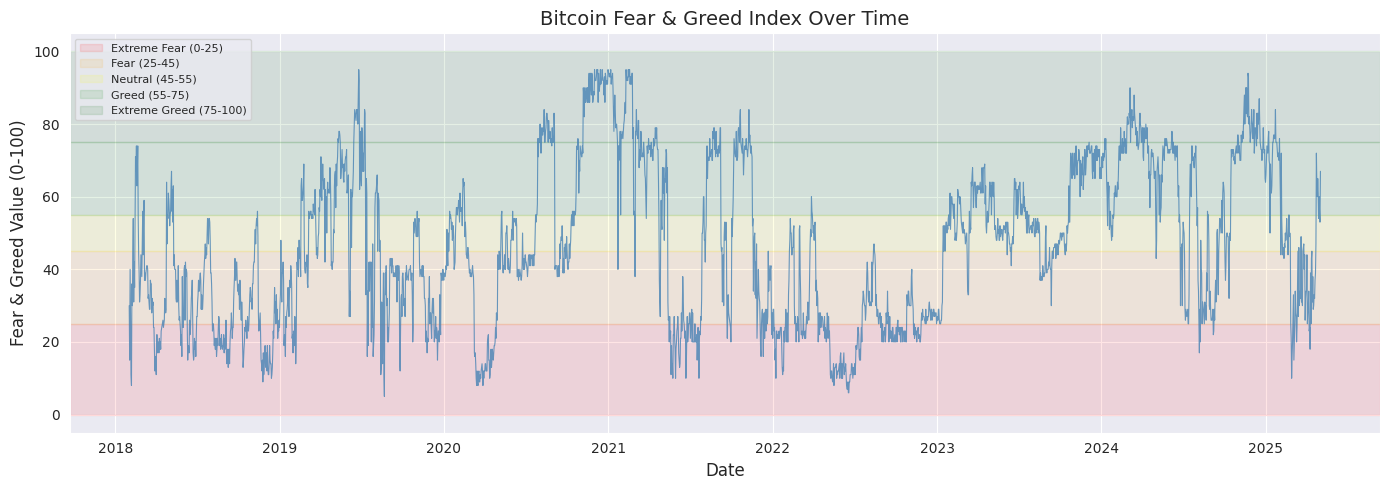

In [28]:
# Plot 2: Fear & Greed Index Over Time
plt.figure(figsize=(14, 5))
plt.plot(fg_df['date'], fg_df['fg_value'], linewidth=0.8, color='steelblue', alpha=0.8)

# Add colored horizontal bands
plt.axhspan(0,  25, alpha=0.1, color='red',    label='Extreme Fear (0-25)')
plt.axhspan(25, 45, alpha=0.1, color='orange', label='Fear (25-45)')
plt.axhspan(45, 55, alpha=0.1, color='yellow', label='Neutral (45-55)')
plt.axhspan(55, 75, alpha=0.1, color='green',  label='Greed (55-75)')
plt.axhspan(75, 100,alpha=0.1, color='darkgreen', label='Extreme Greed (75-100)')

plt.title('Bitcoin Fear & Greed Index Over Time')
plt.xlabel('Date')
plt.ylabel('Fear & Greed Value (0-100)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('plot2_fg_over_time.png', dpi=150)
plt.show()

**Trader Analysis**

In [29]:
print('Trader PnL Summary')
print(trader_df[pnl_col].describe())

print(f'\nTotal trades:      {len(trader_df)}')
print(f'Winning trades:    {(trader_df[pnl_col] > 0).sum()}')
print(f'Losing trades:     {(trader_df[pnl_col] < 0).sum()}')
print(f'Break-even trades: {(trader_df[pnl_col] == 0).sum()}')
win_rate = (trader_df[pnl_col] > 0).mean() * 100
print(f'\nOverall Win Rate:  {win_rate:.2f}%')

Trader PnL Summary
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: closed_pnl, dtype: float64

Total trades:      211224
Winning trades:    86869
Losing trades:     17539
Break-even trades: 106816

Overall Win Rate:  41.13%


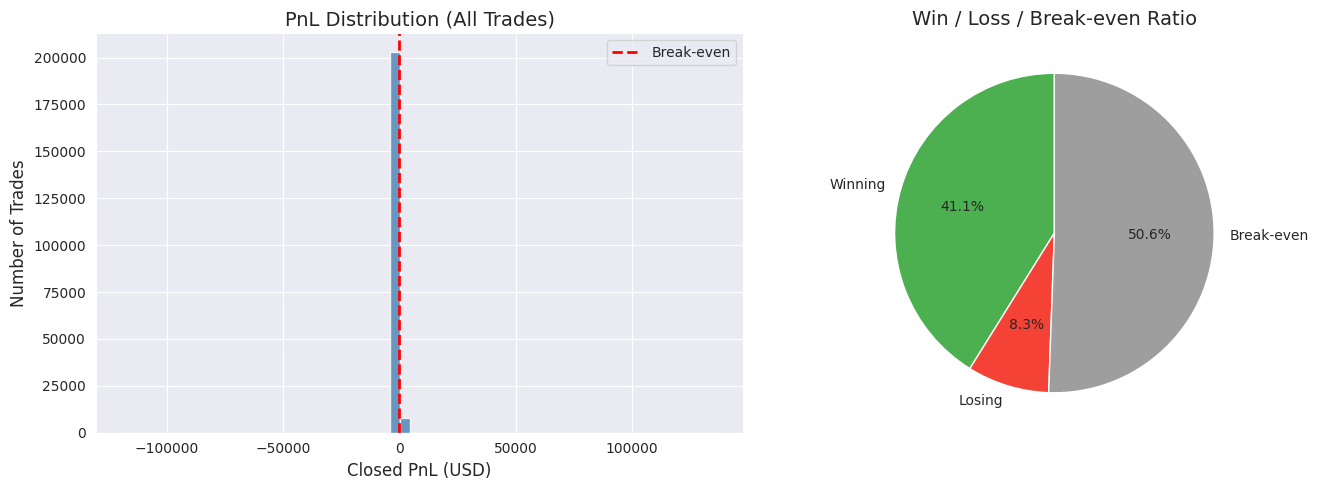

In [30]:
# Plot 3: PnL Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of PnL
axes[0].hist(trader_df[pnl_col], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--', label='Break-even')
axes[0].set_title('PnL Distribution (All Trades)')
axes[0].set_xlabel('Closed PnL (USD)')
axes[0].set_ylabel('Number of Trades')
axes[0].legend()

# Win vs Loss pie
win_loss = ['Winning', 'Losing', 'Break-even']
wl_counts = [
    (trader_df[pnl_col] > 0).sum(),
    (trader_df[pnl_col] < 0).sum(),
    (trader_df[pnl_col] == 0).sum()
]
axes[1].pie(wl_counts, labels=win_loss, autopct='%1.1f%%',
            colors=['#4caf50', '#f44336', '#9e9e9e'], startangle=90)
axes[1].set_title('Win / Loss / Break-even Ratio')

plt.tight_layout()
plt.savefig('plot3_pnl_distribution.png', dpi=150)
plt.show()

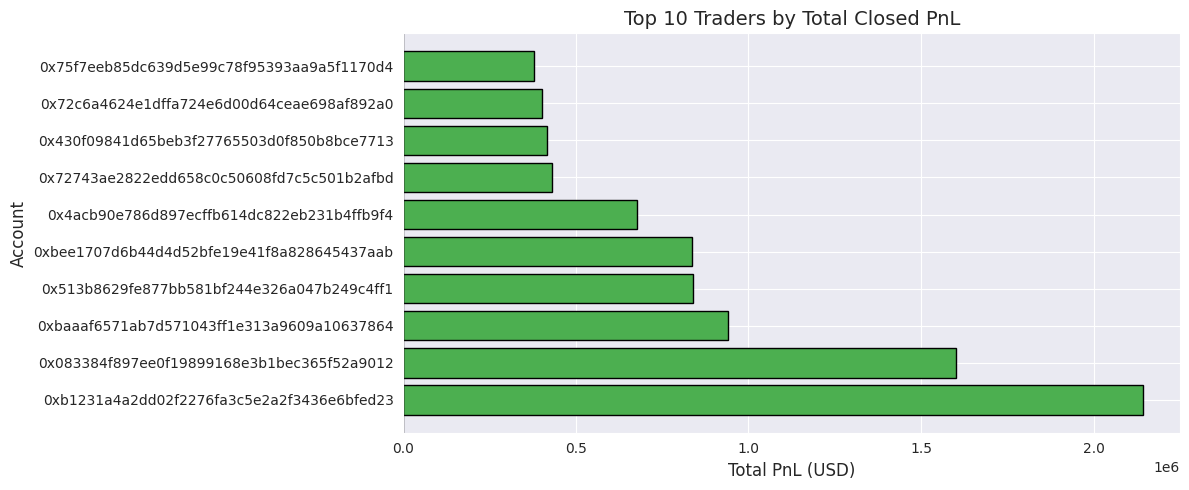

In [31]:
# Top 10 traders by total PnL
top_traders = (
    trader_df.groupby('account')[pnl_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
colors = ['#4caf50' if v > 0 else '#f44336' for v in top_traders.values]
bars = plt.barh(top_traders.index, top_traders.values, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 10 Traders by Total Closed PnL')
plt.xlabel('Total PnL (USD)')
plt.ylabel('Account')
plt.tight_layout()
plt.savefig('plot4_top_traders.png', dpi=150)
plt.show()

In [32]:
# Long vs Short trade analysis
side_col = 'side'

side_pnl = trader_df.groupby(side_col)[pnl_col].agg(['mean', 'sum', 'count'])
side_pnl.columns = ['Avg PnL', 'Total PnL', 'Trade Count']
print('=== Long vs Short Performance ===')
print(side_pnl)

=== Long vs Short Performance ===
        Avg PnL     Total PnL  Trade Count
side                                      
BUY   36.104730  3.707811e+06       102696
SELL  60.713803  6.589148e+06       108528


In [33]:
# Merging trader data with fear & greed on date
merged = pd.merge(trader_df, fg_df, on='date', how='inner')

print(f'Trader rows:      {len(trader_df)}')
print(f'After merge:      {len(merged)}')
print(f'Date range:       {merged["date"].min().date()} → {merged["date"].max().date()}')
print(f'Sentiment values: {merged["sentiment"].unique()}')
merged.head()

Trader rows:      211224
After merge:      184263
Date range:       2023-03-28 → 2025-02-19
Sentiment values: ['Greed' 'Fear' 'Extreme Greed' 'Neutral']


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,fg_value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,74,Greed


In [34]:
# Checking How many trades happened under each sentiment?
trades_per_sentiment = merged['sentiment'].value_counts()
print('Trades per Sentiment Bucket:')
print(trades_per_sentiment)

Trades per Sentiment Bucket:
sentiment
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [35]:
# Average PnL per sentiment bucket
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

perf_by_sentiment = (
    merged.groupby('sentiment')[pnl_col]
    .agg(['mean', 'median', 'sum', 'count', 'std'])
    .reindex([s for s in sentiment_order if s in merged['sentiment'].unique()])
)
perf_by_sentiment.columns = ['Mean PnL', 'Median PnL', 'Total PnL', 'Trade Count', 'Std Dev']

# Win rate per sentiment
def win_rate(series):
    return (series > 0).mean() * 100

perf_by_sentiment['Win Rate %'] = (
    merged.groupby('sentiment')[pnl_col].apply(win_rate)
    .reindex(perf_by_sentiment.index)
)

print('=== Performance by Market Sentiment ===')
perf_by_sentiment.round(2)

=== Performance by Market Sentiment ===


,Mean PnL,Median PnL,Total PnL,Trade Count,Std Dev,Win Rate %
sentiment,,,,,,
Fear,50.05,0.0,6699925.19,133871,909.12,41.51
Neutral,22.23,0.0,158742.38,7141,633.70,31.72
Greed,87.89,0.0,3189616.54,36289,1148.34,44.65
Extreme Greed,25.42,0.0,176965.49,6962,306.17,49.01


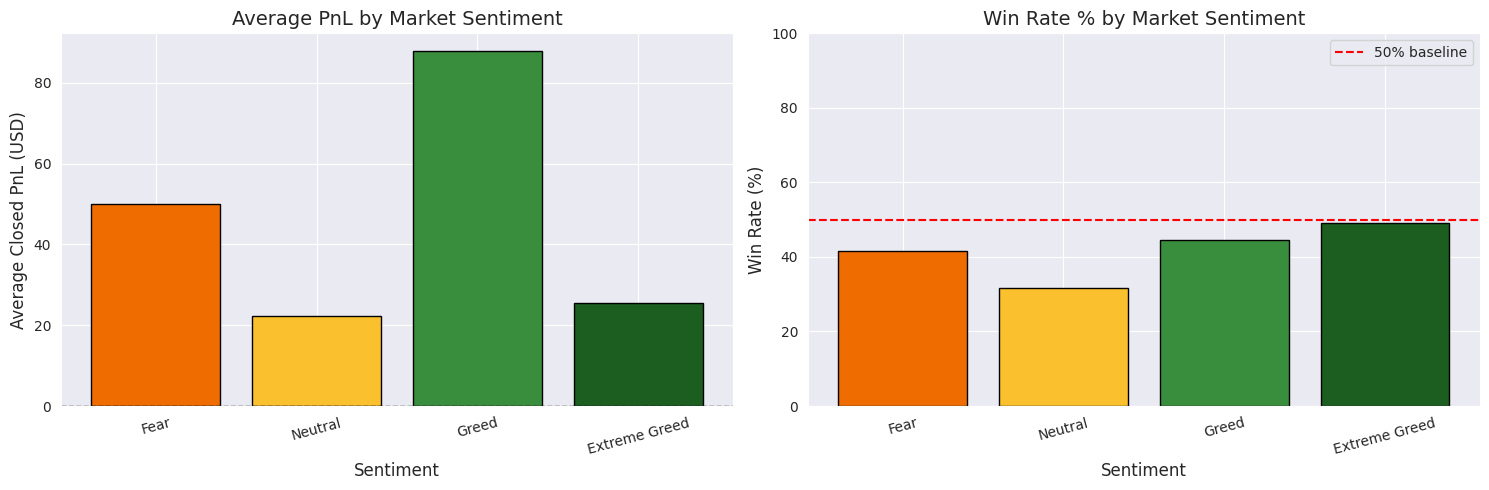

In [36]:
# Plot 5: Mean PnL by Sentiment
present_sentiments = perf_by_sentiment.index.tolist()
colors = ['#d32f2f', '#ef6c00', '#fbc02d', '#388e3c', '#1b5e20']
plot_colors = [colors[sentiment_order.index(s)] for s in present_sentiments]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mean PnL
bars = axes[0].bar(present_sentiments, perf_by_sentiment['Mean PnL'],
                   color=plot_colors, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Average PnL by Market Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Average Closed PnL (USD)')
axes[0].tick_params(axis='x', rotation=15)

# Win Rate
axes[1].bar(present_sentiments, perf_by_sentiment['Win Rate %'],
            color=plot_colors, edgecolor='black')
axes[1].axhline(50, color='red', linewidth=1.5, linestyle='--', label='50% baseline')
axes[1].set_title('Win Rate % by Market Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot5_performance_by_sentiment.png', dpi=150)
plt.show()

/tmp/ipykernel_1139/1991692906.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_per_sentiment, labels=present, patch_artist=True,


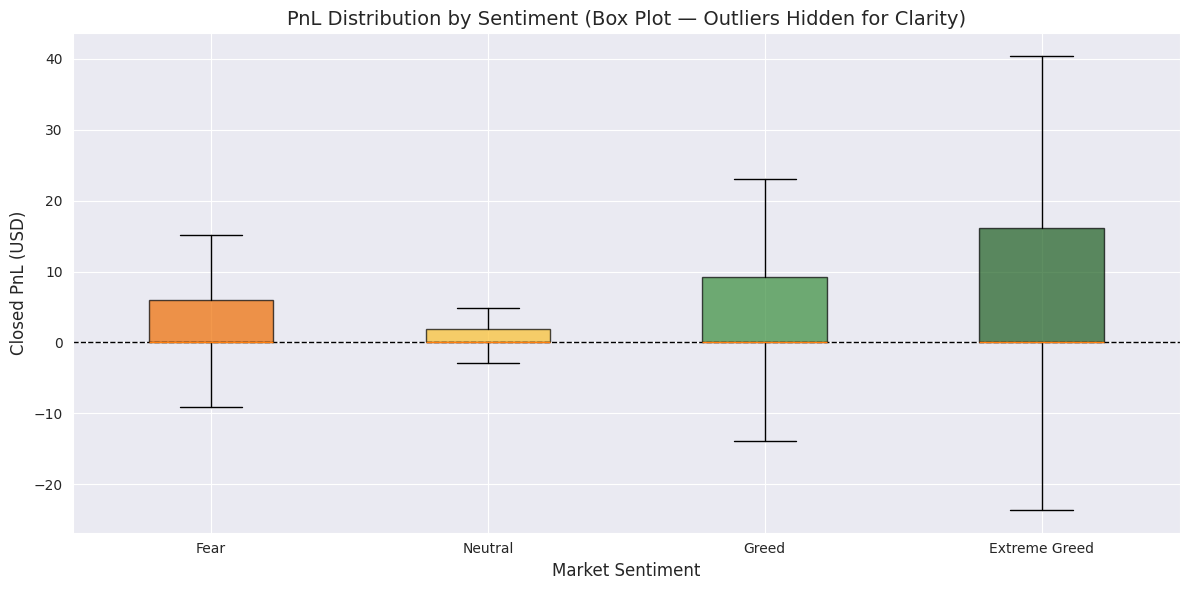

In [37]:
# Plot 6: Box plot — PnL distribution per sentiment (shows spread + outliers)
plt.figure(figsize=(12, 6))

present = [s for s in sentiment_order if s in merged['sentiment'].unique()]
data_per_sentiment = [merged[merged['sentiment'] == s][pnl_col].values for s in present]

bp = plt.boxplot(data_per_sentiment, labels=present, patch_artist=True,
                 notch=False, showfliers=False)  # showfliers=False removes extreme outliers from view

for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('PnL Distribution by Sentiment (Box Plot — Outliers Hidden for Clarity)')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL (USD)')
plt.tight_layout()
plt.savefig('plot6_boxplot_pnl_sentiment.png', dpi=150)
plt.show()

#Identifying Patterns

=== Mean PnL: Long vs Short by Sentiment ===
side             BUY    SELL
sentiment                   
Fear           58.07   42.22
Neutral        15.65   28.58
Greed          12.49  143.62
Extreme Greed  25.58   25.27


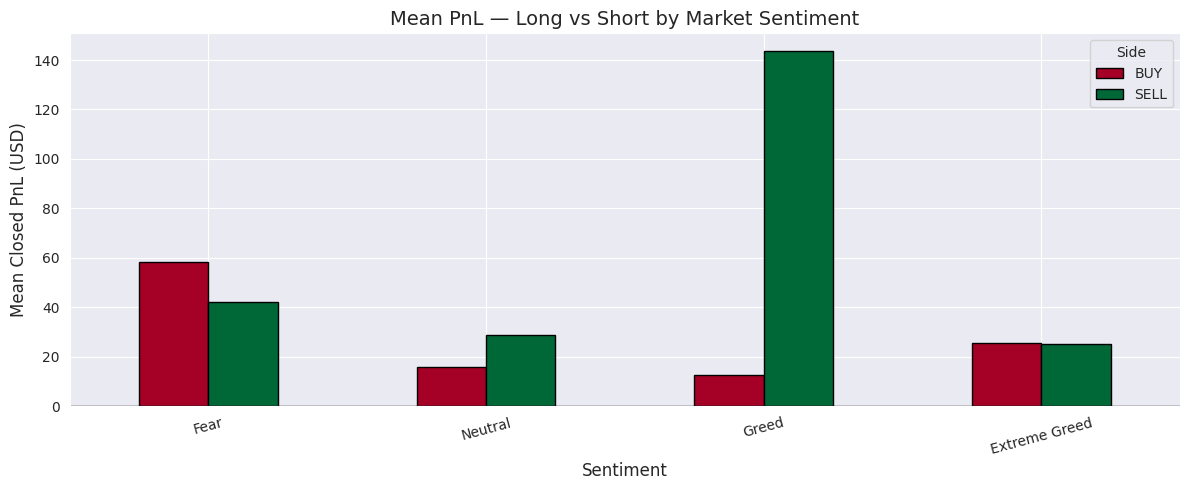

In [39]:
# Pattern 1: Long vs Short performance per sentiment
long_short_sentiment = (
    merged.groupby(['sentiment', side_col])[pnl_col]
    .mean()
    .unstack()
    .reindex([s for s in sentiment_order if s in merged['sentiment'].unique()])
)

print('=== Mean PnL: Long vs Short by Sentiment ===')
print(long_short_sentiment.round(2))

# Plot
long_short_sentiment.plot(kind='bar', figsize=(12, 5), colormap='RdYlGn', edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title('Mean PnL — Long vs Short by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Mean Closed PnL (USD)')
plt.xticks(rotation=15)
plt.legend(title='Side')
plt.tight_layout()
plt.savefig('plot7_longshort_by_sentiment.png', dpi=150)
plt.show()

Pearson Correlation (FG value vs Avg Daily PnL): 0.0874
P-value: 0.8692
→ Correlation is NOT statistically significant.


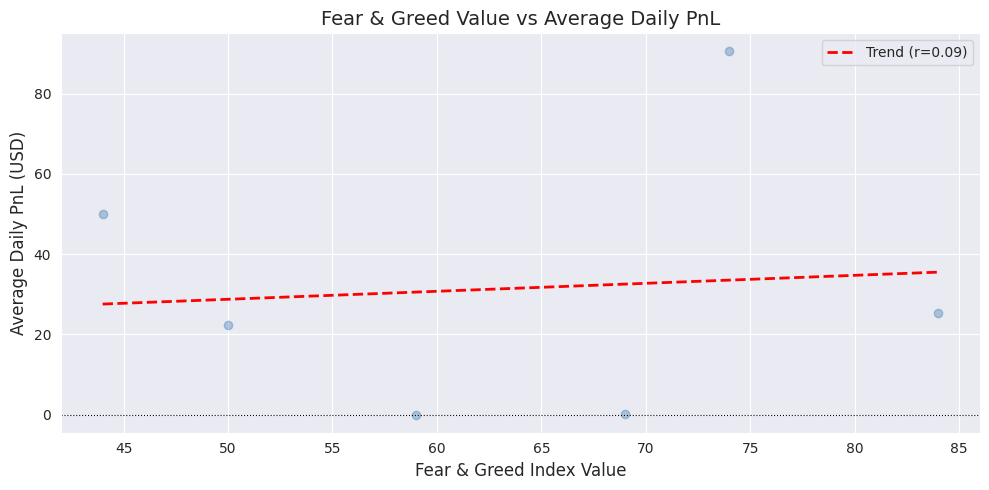

In [40]:
#Pattern 2: Correlation — FG value vs PnL
daily_pnl = merged.groupby('date').agg(
    total_pnl=(pnl_col, 'sum'),
    avg_pnl=(pnl_col, 'mean'),
    fg_value=('fg_value', 'first')
).reset_index()

corr, p_value = stats.pearsonr(daily_pnl['fg_value'], daily_pnl['avg_pnl'])
print(f'Pearson Correlation (FG value vs Avg Daily PnL): {corr:.4f}')
print(f'P-value: {p_value:.4f}')
if p_value < 0.05:
    print('→ Statistically significant correlation!')
else:
    print('→ Correlation is NOT statistically significant.')

# Scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(daily_pnl['fg_value'], daily_pnl['avg_pnl'], alpha=0.4, color='steelblue')
# Trend line
z = np.polyfit(daily_pnl['fg_value'], daily_pnl['avg_pnl'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily_pnl['fg_value'].min(), daily_pnl['fg_value'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (r={corr:.2f})')
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.title('Fear & Greed Value vs Average Daily PnL')
plt.xlabel('Fear & Greed Index Value')
plt.ylabel('Average Daily PnL (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('plot8_correlation_scatter.png', dpi=150)
plt.show()

Top 5 Traders: Mean PnL per Sentiment
sentiment                                     Fear  Neutral   Greed  \
account                                                               
0x083384f897ee0f19899168e3b1bec365f52a9012  574.41      NaN -708.89   
0x513b8629fe877bb581bf244e326a047b249c4ff1   69.85      NaN    0.00   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   75.04    38.09  615.28   
0xbaaaf6571ab7d571043ff1e313a9609a10637864   44.37      NaN     NaN   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    4.76      NaN   69.23   

sentiment                                   Extreme Greed  
account                                                    
0x083384f897ee0f19899168e3b1bec365f52a9012            NaN  
0x513b8629fe877bb581bf244e326a047b249c4ff1            NaN  
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23           0.85  
0xbaaaf6571ab7d571043ff1e313a9609a10637864            NaN  
0xbee1707d6b44d4d52bfe19e41f8a828645437aab            NaN  


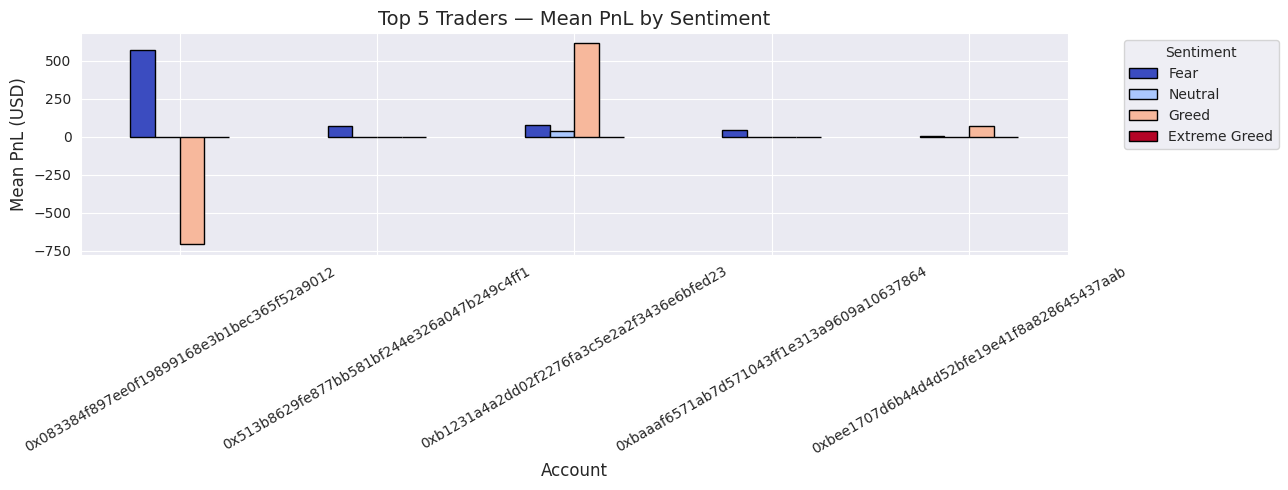

In [41]:
# Pattern 3: Top trader behaviour — do they trade differently in fear vs greed?
top_5_accounts = trader_df.groupby('account')[pnl_col].sum().nlargest(5).index.tolist()

top_trader_sentiment = (
    merged[merged['account'].isin(top_5_accounts)]
    .groupby(['account', 'sentiment'])[pnl_col]
    .mean()
    .unstack()
    .reindex(columns=[s for s in sentiment_order if s in merged['sentiment'].unique()])
)

print('Top 5 Traders: Mean PnL per Sentiment')
print(top_trader_sentiment.round(2))

top_trader_sentiment.plot(kind='bar', figsize=(13, 5), colormap='coolwarm', edgecolor='black')
plt.title('Top 5 Traders — Mean PnL by Sentiment')
plt.xlabel('Account')
plt.ylabel('Mean PnL (USD)')
plt.xticks(rotation=30)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot9_top_traders_sentiment.png', dpi=150)
plt.show()

In [49]:
from scipy.stats import f_oneway

# Group PnL values by sentiment
groups = [merged[merged['sentiment'] == s][pnl_col].dropna().values
          for s in present_sentiments]

f_stat, p_val = f_oneway(*groups)

print('One-Way ANOVA Test')
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value:     {p_val:.6f}')
if p_val < 0.05:
    print('\n Result: PnL differs SIGNIFICANTLY across sentiment groups (p < 0.05)')
    print('→ Market sentiment has a statistically significant impact on trader PnL!')
else:
    print('\n Result: No significant difference found across sentiment groups (p ≥ 0.05)')

One-Way ANOVA Test
F-statistic: 21.3304
P-value:     0.000000

 Result: PnL differs SIGNIFICANTLY across sentiment groups (p < 0.05)
→ Market sentiment has a statistically significant impact on trader PnL!


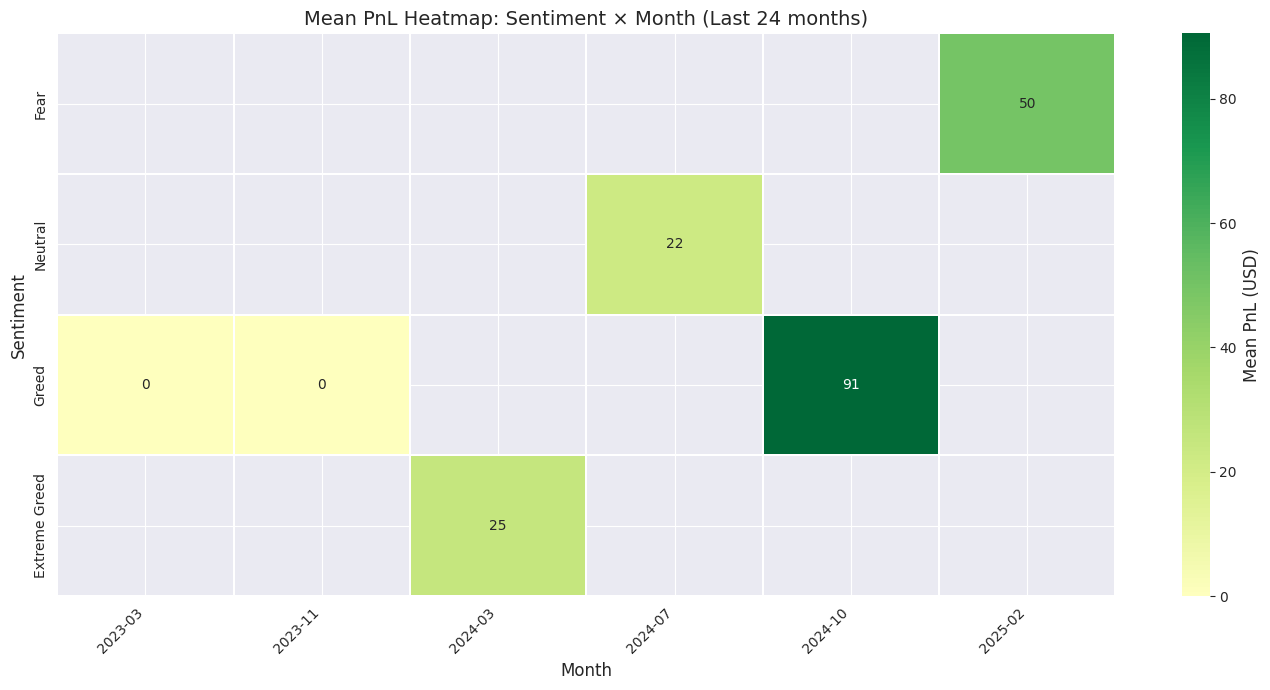

In [42]:
#Pattern 4: Monthly performance heatmap
merged['month'] = merged['date'].dt.to_period('M')

monthly_pnl = (
    merged.groupby(['month', 'sentiment'])[pnl_col]
    .mean()
    .unstack()
    .reindex(columns=[s for s in sentiment_order if s in merged['sentiment'].unique()])
)

# Only keep recent months for readability
monthly_pnl = monthly_pnl.tail(24)

plt.figure(figsize=(14, 7))
sns.heatmap(
    monthly_pnl.T,
    cmap='RdYlGn',
    center=0,
    linewidths=0.3,
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Mean PnL (USD)'}
)
plt.title('Mean PnL Heatmap: Sentiment × Month (Last 24 months)')
plt.xlabel('Month')
plt.ylabel('Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot10_monthly_heatmap.png', dpi=150)
plt.show()

#Key Insights & Conclusions

In [48]:
print('=' * 60)
print('       KEY INSIGHTS FROM THE ANALYSIS')
print('=' * 60)

best_sentiment = perf_by_sentiment['Mean PnL'].idxmax()
worst_sentiment = perf_by_sentiment['Mean PnL'].idxmin()
best_win_rate_s = perf_by_sentiment['Win Rate %'].idxmax()

# Calculate overall win rate here directly (avoids the name conflict)
overall_win_rate = (merged[pnl_col] > 0).mean() * 100

print(f"""
1. BEST sentiment to trade in → {best_sentiment}
   (Highest average PnL: ${perf_by_sentiment.loc[best_sentiment, 'Mean PnL']:.2f})

2. WORST sentiment to trade in → {worst_sentiment}
   (Lowest average PnL: ${perf_by_sentiment.loc[worst_sentiment, 'Mean PnL']:.2f})

3. Highest Win Rate sentiment → {best_win_rate_s}
   (Win rate: {perf_by_sentiment.loc[best_win_rate_s, 'Win Rate %']:.1f}%)

4. Correlation between Fear/Greed value & PnL: {corr:.4f}
   {'(Positive: higher greed → higher PnL)' if corr > 0 else '(Negative: higher fear → higher PnL)'}

5. Overall trader win rate: {overall_win_rate:.1f}%
""")

print('=' * 60)
print('       TRADING STRATEGY RECOMMENDATIONS')
print('=' * 60)
print("""
→ Consider increasing position sizes during periods of market
  sentiment that historically showed higher PnL.

→ Be more cautious (reduce leverage, smaller sizes) during
  extreme fear or extreme greed — volatility is highest.

→ Long vs Short strategy: check plot 7 above to see which
  direction works best in each sentiment bucket.

→ Use the Fear & Greed Index as an early signal — it can
  give you a daily edge on which side to lean.
""")

       KEY INSIGHTS FROM THE ANALYSIS

1. BEST sentiment to trade in → Greed
   (Highest average PnL: $87.89)

2. WORST sentiment to trade in → Neutral
   (Lowest average PnL: $22.23)

3. Highest Win Rate sentiment → Extreme Greed
   (Win rate: 49.0%)

4. Correlation between Fear/Greed value & PnL: 0.0874
   (Positive: higher greed → higher PnL)

5. Overall trader win rate: 42.0%

       TRADING STRATEGY RECOMMENDATIONS

→ Consider increasing position sizes during periods of market
  sentiment that historically showed higher PnL.

→ Be more cautious (reduce leverage, smaller sizes) during
  extreme fear or extreme greed — volatility is highest.

→ Long vs Short strategy: check plot 7 above to see which
  direction works best in each sentiment bucket.

→ Use the Fear & Greed Index as an early signal — it can
  give you a daily edge on which side to lean.



In [50]:
from google.colab import files

merged.to_csv('merged_trader_sentiment.csv', index=False)
files.download('merged_trader_sentiment.csv')
print('downloading')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloading
